In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

In [3]:
# import file csv 
df = pd.read_csv('C:\Dibimbing\Marketing Analysis\Dataset\\ab_testing_dataset_100k.csv')

In [4]:
# Memuat seluruh kolom dataframe
pd.set_option("display.max_colwidth", None)

In [5]:
# 5 row teratas dataframe
df.head()

,user_id,variant,date,device,browser,country,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,traffic_source,gender,age
0,1,A,2025-01-09,Mobile,Chrome,TH,10,0,0,0,100000,122,1,TikTok Ads,M,20
1,2,B,2025-01-04,Tablet,Edge,ID,6,1,0,0,50000,325,24,Organic,F,21
2,3,A,2025-01-06,Mobile,Firefox,MY,4,0,0,0,200000,446,25,Google Ads,F,38
3,4,A,2025-01-24,Tablet,Safari,TH,2,1,1,0,50000,441,11,Organic,F,42
4,5,A,2025-01-26,Desktop,Edge,ID,5,0,0,0,100000,188,26,TikTok Ads,F,40


In [6]:
# Informasi dasar dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_id           100000 non-null  int64 
 1   variant           100000 non-null  object
 2   date              100000 non-null  object
 3   device            100000 non-null  object
 4   browser           100000 non-null  object
 5   country           100000 non-null  object
 6   page_view         100000 non-null  int64 
 7   click             100000 non-null  int64 
 8   add_to_cart       100000 non-null  int64 
 9   purchase          100000 non-null  int64 
 10  revenue           100000 non-null  int64 
 11  session_duration  100000 non-null  int64 
 12  impressions       100000 non-null  int64 
 13  traffic_source    100000 non-null  object
 14  gender            100000 non-null  object
 15  age               100000 non-null  int64 
dtypes: int64(9), object(7)
memory usage: 12

In [7]:
df.shape

(100000, 16)

- jumlah baris: 100.000
- jumlah kolom: 16

In [8]:
# Statistik dasar kolom numerik
df.describe()

,user_id,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,age
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0000,100000.000000,100000.000000,100000.000000
mean,50000.500000,7.484790,0.299250,0.150640,0.070610,124799.0000,314.640710,14.975070,36.049640
std,28867.657797,4.030701,0.457932,0.357699,0.256174,85376.7093,164.450137,8.356514,10.668443
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.0000,30.000000,1.000000,18.000000
25%,25000.750000,4.000000,0.000000,0.000000,0.000000,50000.0000,172.000000,8.000000,27.000000
50%,50000.500000,7.000000,0.000000,0.000000,0.000000,100000.0000,315.000000,15.000000,36.000000
75%,75000.250000,11.000000,1.000000,0.000000,0.000000,200000.0000,457.000000,22.000000,45.000000
max,100000.000000,14.000000,1.000000,1.000000,1.000000,250000.0000,599.000000,29.000000,54.000000


In [9]:
# Statistik dasar kolom objek/kategorik
df.describe(include=['O'])

,variant,date,device,browser,country,traffic_source,gender
count,100000,100000,100000,100000,100000,100000,100000
unique,2,30,3,4,5,4,2
top,B,2025-01-01,Desktop,Edge,TH,Organic,M
freq,50063,3446,33607,25134,20223,25268,50025


In [10]:
# nama-nama kolom dataframe
df.columns

Index(['user_id', 'variant', 'date', 'device', 'browser', 'country',
       'page_view', 'click', 'add_to_cart', 'purchase', 'revenue',
       'session_duration', 'impressions', 'traffic_source', 'gender', 'age'],
      dtype='object')

In [11]:
# tipe data tiap kolom
df.dtypes

user_id              int64
variant             object
date                object
device              object
browser             object
country             object
page_view            int64
click                int64
add_to_cart          int64
purchase             int64
revenue              int64
session_duration     int64
impressions          int64
traffic_source      object
gender              object
age                  int64
dtype: object

- tipe data date masih dalam bentuk object (seharusnya datetime)

In [12]:
# Pemeriksaan missing value
df_na = pd.DataFrame({
	'missing_value' : df.isna().sum(),
	'percentage(%)' : round((df.isna().mean()*100), 2),
	'data_type' : df.dtypes
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df_na["missing_value"].sum()
percentage_total = (total_missing / total_cells) * 100

print(df_na[df_na['missing_value'] > 0].sort_values(by="missing_value", ascending=False))
print("\n")
print("Jumlah missing value: ", total_missing)
print("Persentase missing value (%): ", round(percentage_total, 2))


Empty DataFrame
Columns: [missing_value, percentage(%), data_type]
Index: []


Jumlah missing value:  0
Persentase missing value (%):  0.0


- tidak ada missing value

In [ ]:
# Pemeriksaan unique value
obj_col = df.select_dtypes(include=["object"]).columns
obj_value = []

for col in obj_col:
    obj_value.append({
        "column_name": col,
        "n_unique": df[col].nunique(dropna=True),
        "n_missing": df[col].isna().sum(),
        "top_5_value": df[col].value_counts().head(5).to_dict()
    })

df_obj_value = pd.DataFrame(obj_value)

df_obj_value

,column_name,n_unique,n_missing,top_5_value
0,variant,2,0,"{'B': 50063, 'A': 49937}"
1,date,30,0,"{'2025-01-01': 3446, '2025-01-26': 3445, '2025-01-30': 3421, '2025-01-29': 3420, '2025-01-12': 3415}"
2,device,3,0,"{'Desktop': 33607, 'Mobile': 33315, 'Tablet': 33078}"
3,browser,4,0,"{'Edge': 25134, 'Firefox': 25096, 'Chrome': 24981, 'Safari': 24789}"
4,country,5,0,"{'TH': 20223, 'SG': 20128, 'ID': 19901, 'MY': 19877, 'PH': 19871}"
5,traffic_source,4,0,"{'Organic': 25268, 'Google Ads': 25068, 'TikTok Ads': 24925, 'Instagram': 24739}"
6,gender,2,0,"{'M': 50025, 'F': 49975}"


- distribusi unique value cenderung merata pada setiap kategori nya

In [14]:
col_numeric = df.select_dtypes(include='number').columns[1:]

In [15]:
col_numeric

Index(['page_view', 'click', 'add_to_cart', 'purchase', 'revenue',
       'session_duration', 'impressions', 'age'],
      dtype='object')

In [16]:
# Membuat tabel pemeriksaan outlier
# Metode pemriksaan outlier: IQR
outlier_summary = {}

for n in col_numeric:
    Q1 = df[n].quantile(0.25) # Mendapatkan nilai 25% dari dataset
    Q3 = df[n].quantile(0.75) # Mendapatkan nilai 75% dari dataset
    IQR = Q3 - Q1

    lowerbond = Q1 - 1.5*IQR # Medapatkan nilai batas bawah outlier
    upperbond = Q3 + 1.5*IQR # Medapatkan nilai batas atas outlier

    outlier = df[(df[n] < lowerbond) | (df[n] > upperbond)] # outlier adalah nilai diatas nilai uppperbond atau dibawah lowerbond

    # Variable untuk merangkum perhitungan metode IQR dalam bentuk dictionary
    outlier_summary[n] = {
        "lower_bond" : lowerbond,
        "upper_bond" : upperbond,
        "n_outlier" : len(outlier), # jumlah data yang termasuk outlier
        "percentage" : len(outlier)/len(df[n])*100 # persentase
    }

In [17]:
pd.DataFrame(outlier_summary)

,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,age
lower_bond,-6.5,-1.5,0.000,0.000,-175000.0,-255.5,-13.0,0.0
upper_bond,21.5,2.5,0.000,0.000,425000.0,884.5,43.0,72.0
n_outlier,0.0,0.0,15064.000,7061.000,0.0,0.0,0.0,0.0
percentage,0.0,0.0,15.064,7.061,0.0,0.0,0.0,0.0


In [18]:
# Setting warna visualisasi global
plt.rcParams["figure.facecolor"] = "black"
plt.rcParams["axes.facecolor"] = "black"
plt.rcParams["text.color"] = "white"
plt.rcParams["axes.labelcolor"] = "white"
plt.rcParams["xtick.color"] = "white"
plt.rcParams["ytick.color"] = "white"
# Mengubah warna default komponen boxplot secara global menjadi putih
plt.rcParams["boxplot.boxprops.color"] = "white"
plt.rcParams["boxplot.whiskerprops.color"] = "white"
plt.rcParams["boxplot.capprops.color"] = "white"
plt.rcParams["boxplot.medianprops.color"] = "orange"  # Oranye untuk median

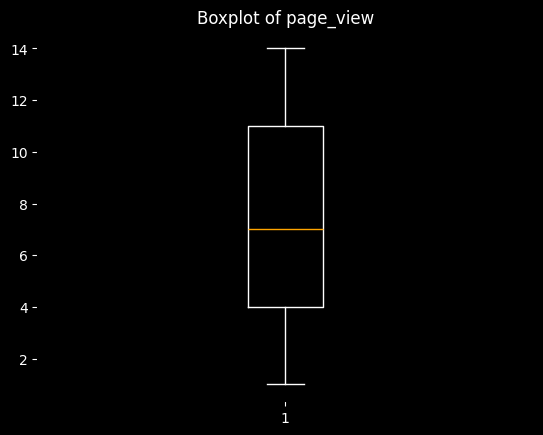

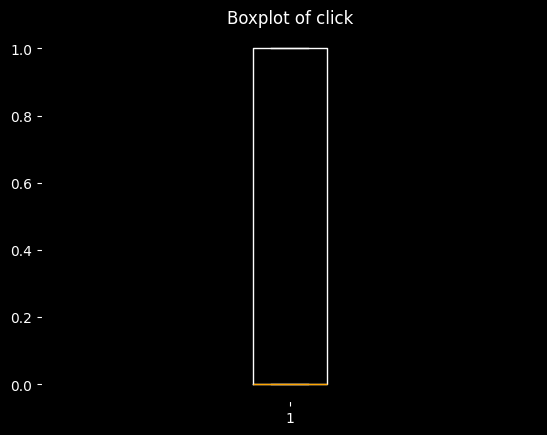

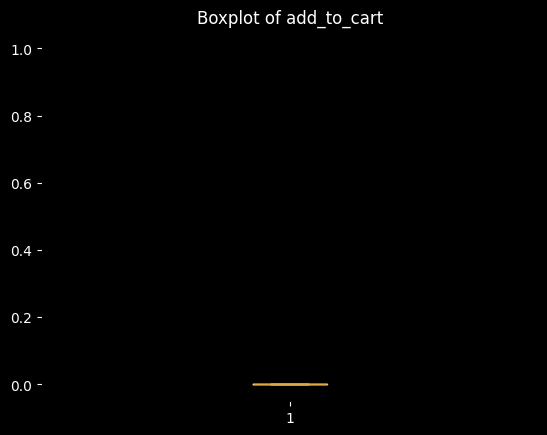

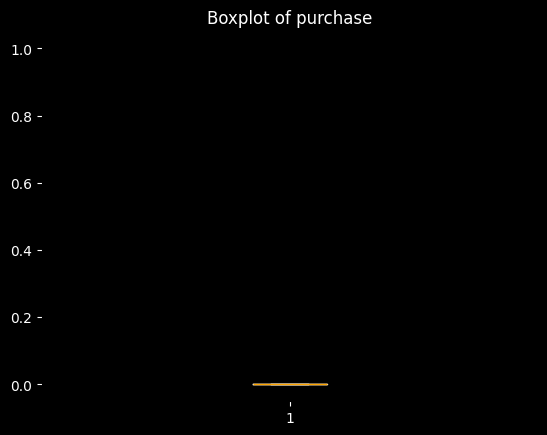

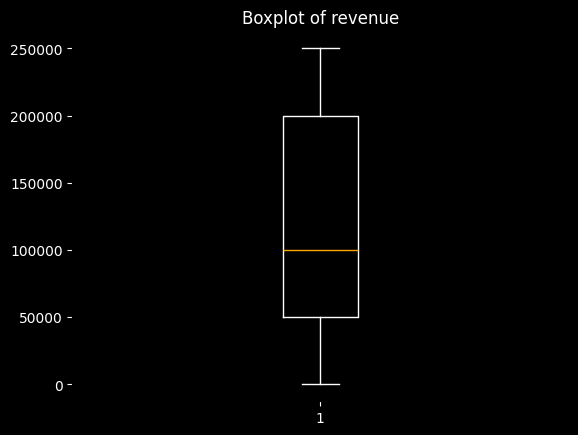

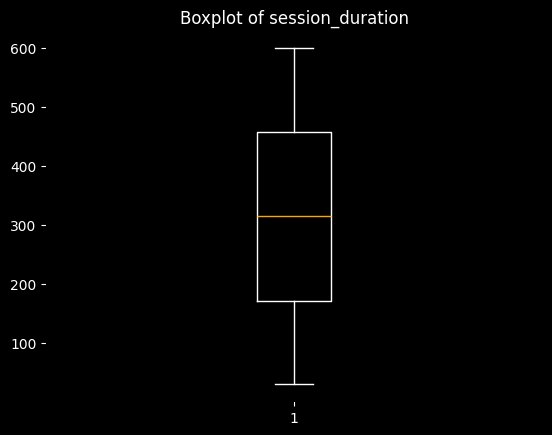

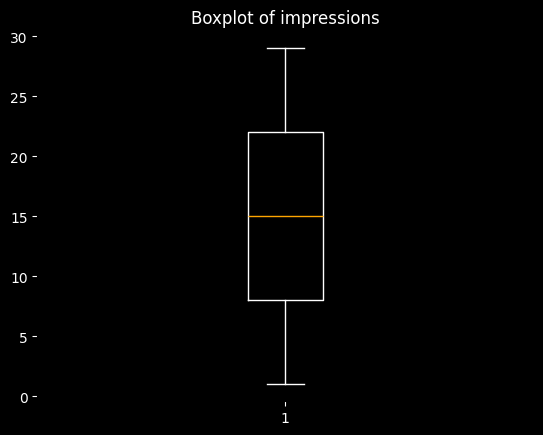

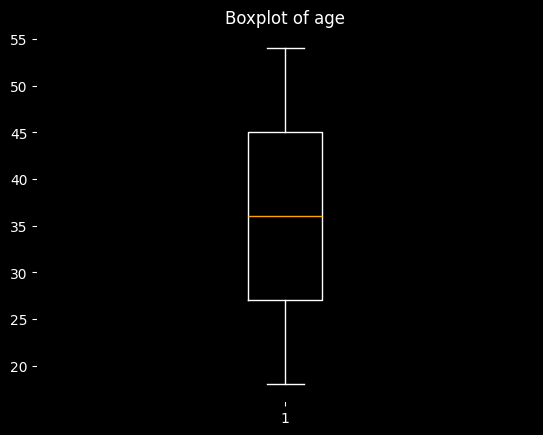

In [19]:
# Membuat boxplot
for n in col_numeric:
    plt.figure()
    plt.boxplot(df[n])
    plt.title(f'Boxplot of {n}')
    plt.show()

In [ ]:
# Periksa duplikasi data
df.duplicated().sum()

np.int64(0)

In [21]:
# Membuat salinan dataframe 
# dfc = dataframecopy
dfc = df.copy()

In [22]:
dfc.head()

,user_id,variant,date,device,browser,country,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,traffic_source,gender,age
0,1,A,2025-01-09,Mobile,Chrome,TH,10,0,0,0,100000,122,1,TikTok Ads,M,20
1,2,B,2025-01-04,Tablet,Edge,ID,6,1,0,0,50000,325,24,Organic,F,21
2,3,A,2025-01-06,Mobile,Firefox,MY,4,0,0,0,200000,446,25,Google Ads,F,38
3,4,A,2025-01-24,Tablet,Safari,TH,2,1,1,0,50000,441,11,Organic,F,42
4,5,A,2025-01-26,Desktop,Edge,ID,5,0,0,0,100000,188,26,TikTok Ads,F,40


In [23]:
# Ubah data object menjadi date time pada kolom date
dfc['date'] = pd.to_datetime(dfc['date'], errors='coerce')

In [ ]:
# Membuat kolom age group
# kategori umur berdasarkan rentan umur tertentu
dfc['age_group'] = pd.cut(
    dfc['age'],
    bins=[18,25,35,50,100],
    labels=['18-24','25-34','35-49','50+'],
    right=False
)

In [ ]:
# Membnuat kolom baru funnel stage
# katregori aksi terakhir yang dilakukan user
def funnel_stage(row):
    if row['purchase'] == 1:
        return 'Purchase'
    elif row['add_to_cart'] == 1:
        return 'Add to Cart'
    elif row['click'] == 1:
        return 'Click'
    else:
        return 'View'

dfc['funnel_stage'] = dfc.apply(funnel_stage, axis=1)

In [26]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           100000 non-null  int64         
 1   variant           100000 non-null  object        
 2   date              100000 non-null  datetime64[ns]
 3   device            100000 non-null  object        
 4   browser           100000 non-null  object        
 5   country           100000 non-null  object        
 6   page_view         100000 non-null  int64         
 7   click             100000 non-null  int64         
 8   add_to_cart       100000 non-null  int64         
 9   purchase          100000 non-null  int64         
 10  revenue           100000 non-null  int64         
 11  session_duration  100000 non-null  int64         
 12  impressions       100000 non-null  int64         
 13  traffic_source    100000 non-null  object        
 14  gende

In [27]:
dfc

,user_id,variant,date,device,browser,country,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,traffic_source,gender,age,age_group,funnel_stage
0,1,A,2025-01-09,Mobile,Chrome,TH,10,0,0,0,100000,122,1,TikTok Ads,M,20,18-24,View
1,2,B,2025-01-04,Tablet,Edge,ID,6,1,0,0,50000,325,24,Organic,F,21,18-24,Click
2,3,A,2025-01-06,Mobile,Firefox,MY,4,0,0,0,200000,446,25,Google Ads,F,38,35-49,View
3,4,A,2025-01-24,Tablet,Safari,TH,2,1,1,0,50000,441,11,Organic,F,42,35-49,Add to Cart
4,5,A,2025-01-26,Desktop,Edge,ID,5,0,0,0,100000,188,26,TikTok Ads,F,40,35-49,View
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,A,2025-01-11,Desktop,Chrome,ID,12,0,0,0,50000,177,26,TikTok Ads,F,47,35-49,View
99996,99997,B,2025-01-22,Desktop,Chrome,PH,5,0,0,1,100000,255,28,TikTok Ads,F,51,50+,Purchase
99997,99998,A,2025-01-20,Tablet,Firefox,SG,13,0,0,0,100000,205,28,Instagram,M,38,35-49,View
99998,99999,B,2025-01-02,Mobile,Chrome,TH,10,0,1,0,150000,559,18,Instagram,M,47,35-49,Add to Cart


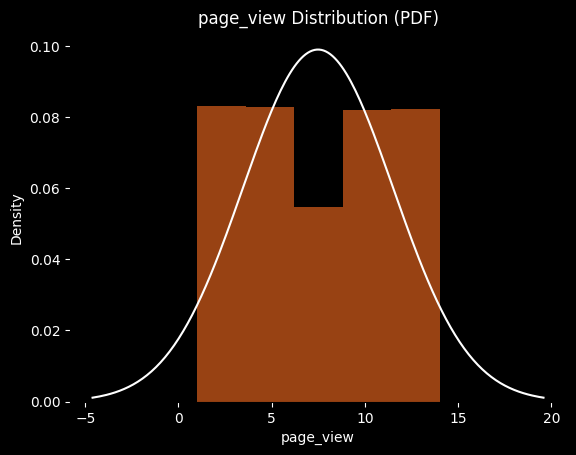

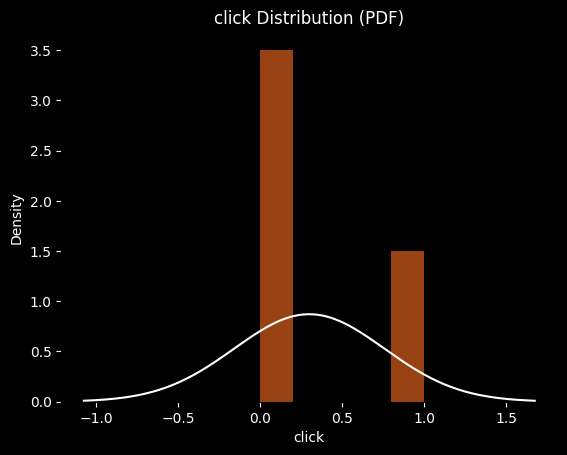

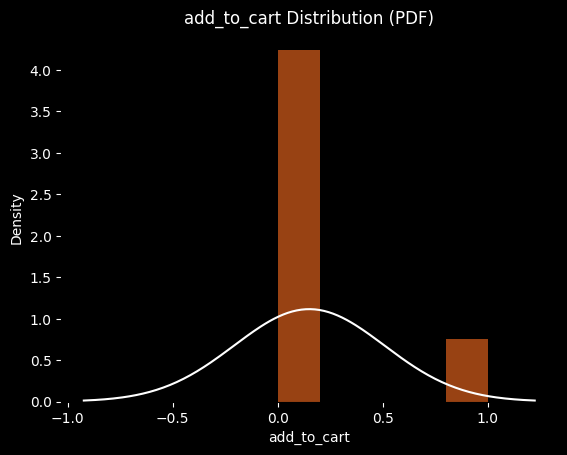

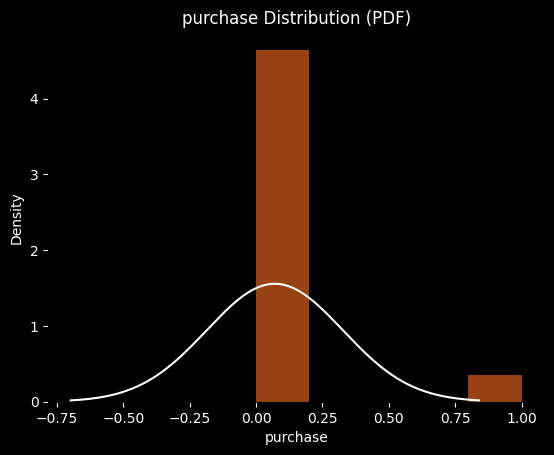

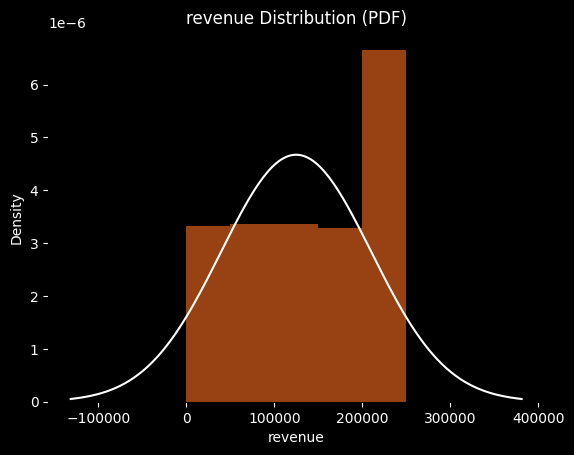

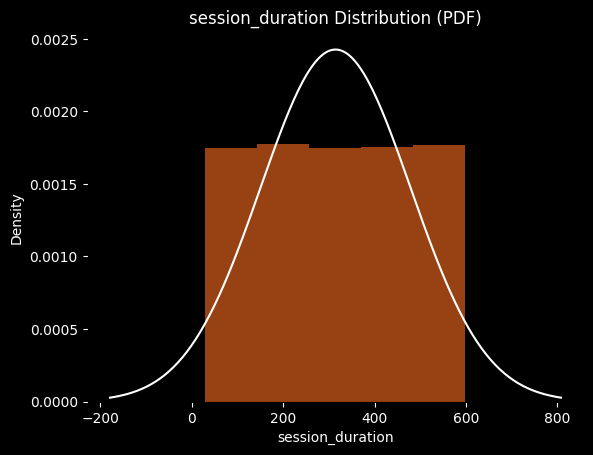

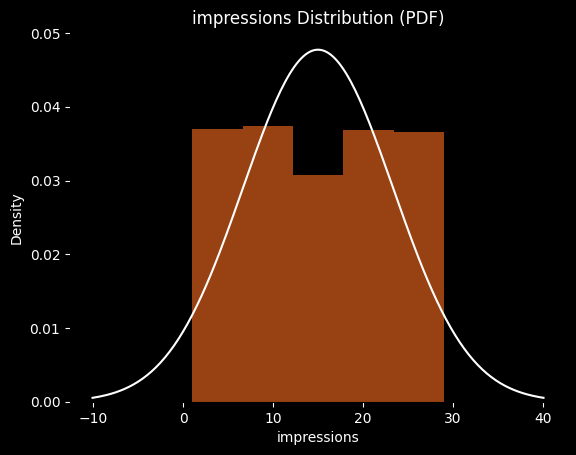

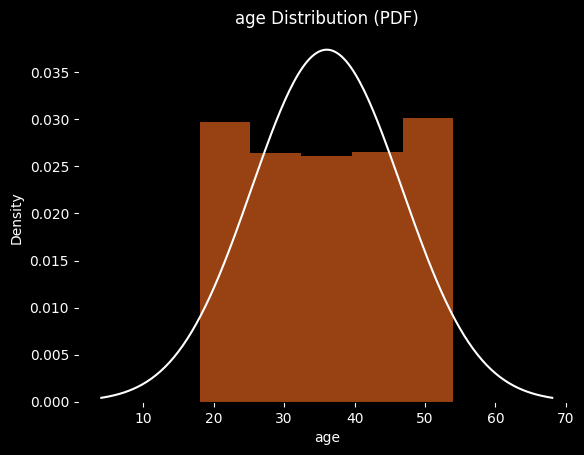

In [ ]:
# Memabuat histrogram untuk melaukan pemeriksaan distribusi kerapatan data
dfc_col_num = dfc.select_dtypes(include='number').columns[1:]
# Membuat garis normalitas
for col in dfc_col_num:
    mu = dfc[col].mean()
    sigma = np.std(dfc[col])
    x = np.linspace(mu - 3*sigma, mu + 3*sigma, 200) 
    pdf = norm.pdf(x, mu, sigma)

    # Membuat histogram distribusi untuk setiap kolom numerik
    plt.hist(
        dfc[col], 
        bins = 5, 
        density=True, 
        alpha=0.6,
        color= "#FF6F20"
        )
    plt.plot(
        x, 
        pdf, 
        color='white'
        )
    
    plt.title(f"{col} Distribution (PDF)")
    plt.xlabel(f"{col}")
    plt.ylabel("Density")
    plt.show()

In [ ]:
# mencari jumlah data dengan purchase = 0 dan memiliki nilai revenue
data_terfilter = dfc[(dfc['purchase'] == 0) & (dfc['revenue'] > 0)]
total_anomali = len(data_terfilter)

print(total_anomali)

77472


In [29]:
# Membuat dataframe kolom numerik
dfc_num = dfc.select_dtypes(include='number').iloc[:, 1:]

In [30]:
dfc_num

,page_view,click,add_to_cart,purchase,revenue,session_duration,impressions,age
0,10,0,0,0,100000,122,1,20
1,6,1,0,0,50000,325,24,21
2,4,0,0,0,200000,446,25,38
3,2,1,1,0,50000,441,11,42
4,5,0,0,0,100000,188,26,40
...,...,...,...,...,...,...,...,...
99995,12,0,0,0,50000,177,26,47
99996,5,0,0,1,100000,255,28,51
99997,13,0,0,0,100000,205,28,38
99998,10,0,1,0,150000,559,18,47


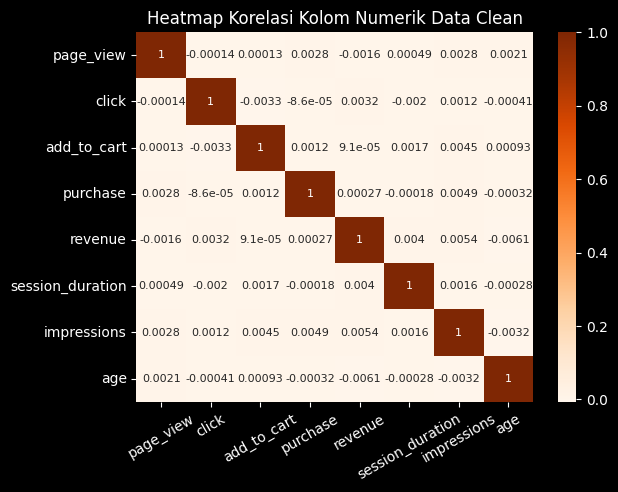

In [31]:
# Membuat heatmap korelasi kolom numerik
corr = dfc_num.corr()

# Heatmap untuk kolom numerik dataframe dfc
sns.heatmap(
    corr, 
    annot=True, 
    annot_kws={'size':8}, 
    cmap='Oranges'
    )

plt.title('Heatmap Korelasi Kolom Numerik Data Clean')
plt.xticks(rotation = 30)
plt.show()

- terdapat indikasi antar kolom numerik memiliki korelasi yang sangat rendah

In [ ]:
# Membuat heatmap untuk melihat korelasi pada kolom object atau kategorik
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k-1, r-1))))

# ambil kolom kategorikal
cat_cols = dfc.select_dtypes(include='object').columns

# buat matrix
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(dfc[col1], dfc[col2])

cramers_matrix = cramers_matrix.astype(float)

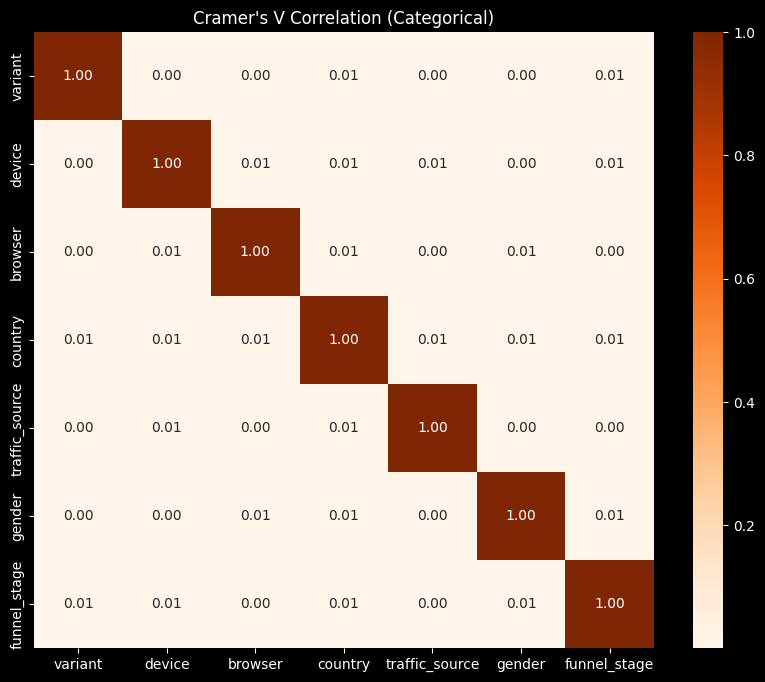

In [33]:
plt.figure(figsize=(10,8))
sns.heatmap(cramers_matrix, annot=True, cmap='Oranges', fmt='.2f')
plt.title("Cramer's V Correlation (Categorical)")
plt.show()

- antar kolom kategorikal cenderung tidak memiliki korelasi

In [34]:
dfc_col_num = dfc.select_dtypes(include='number').iloc[:, 1:]
dfc_col_obj = dfc.select_dtypes(include='O')

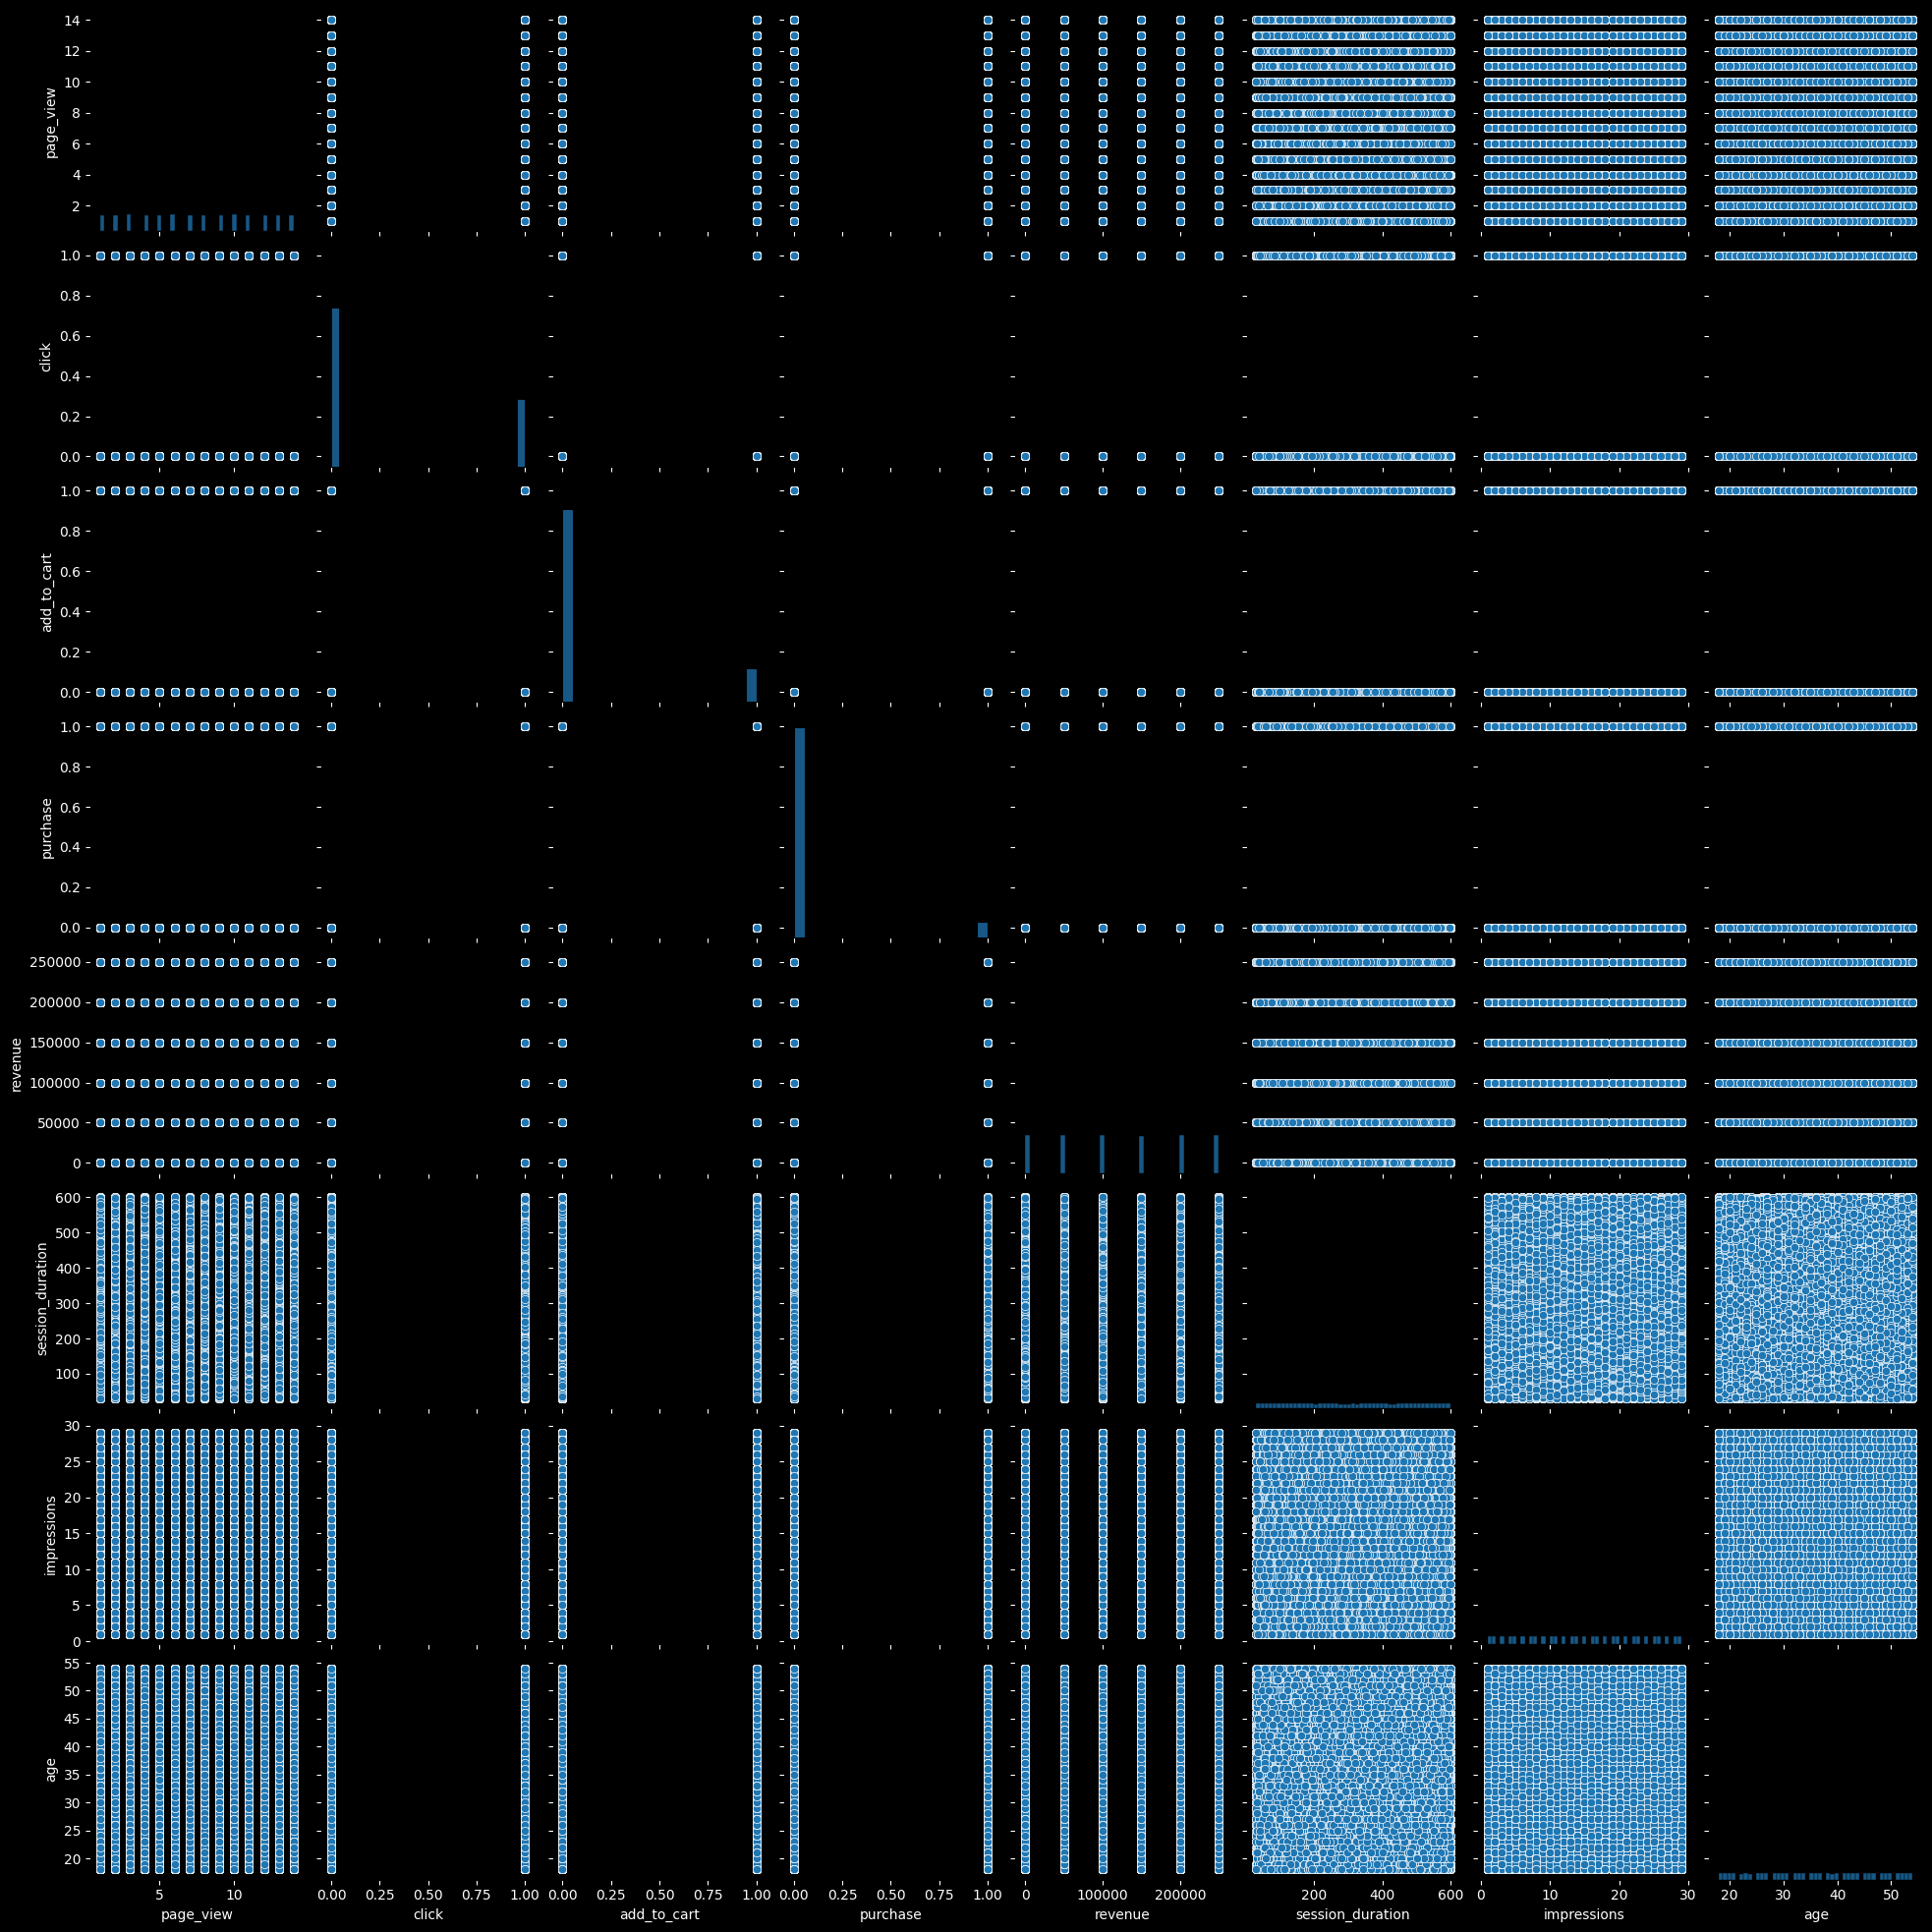

In [ ]:
# membuat pairplot untuk analisa multi variate
sns.pairplot(dfc_col_num)
plt.show()

In [ ]:
# uji hipotesis z-test untuk matrik CTR
click_A = dfc[dfc["variant"] == "A"]["click"].sum()
impression_A = dfc[dfc["variant"] == "A"]["impressions"].sum()

click_B = dfc[dfc["variant"] == "B"]["click"].sum()
impression_B = dfc[dfc["variant"] == "B"]["impressions"].sum()

count = [click_A, click_B]
nobs = [impression_A, impression_B]

z_stat, p_value = proportions_ztest(count, nobs)

print("=== HASIL PERHITUNGAN & UJI Z-TEST: CTR ===")
print(f"Total Click Variant A       : {click_A}")
print(f"Total Impression Variant A  : {impression_A}")
print(f"Total Click Variant B       : {click_B}")
print(f"Total Impression Variant B  : {impression_B}")
print("-" * 43)
print("Z-statistic :", z_stat)
print("P-value     :", p_value)
print("Kesimpulan  :", "SIGNIFIKAN" if p_value < 0.05 else "TIDAK SIGNIFIKAN")

=== HASIL PERHITUNGAN & UJI Z-TEST: CTR ===
Total Click Variant A       : 14805
Total Impression Variant A  : 748911
Total Click Variant B       : 15120
Total Impression Variant B  : 748596
-------------------------------------------
Z-statistic : -1.8761594706459335
P-value     : 0.06063338549471154
Kesimpulan  : TIDAK SIGNIFIKAN


In [ ]:
# uji hipotesis z-test untuk matrik ATCR
cart_A = dfc[dfc["variant"] == "A"]["add_to_cart"].sum()
pv_A = dfc[dfc["variant"] == "A"]["page_view"].sum()

cart_B = dfc[dfc["variant"] == "B"]["add_to_cart"].sum()
pv_B = dfc[dfc["variant"] == "B"]["page_view"].sum()

count = [cart_A, cart_B]
nobs = [pv_A, pv_B]

z_stat, p_value = proportions_ztest(count, nobs)

print("=== HASIL PERHITUNGAN & UJI Z-TEST: ATCR ===")
print(f"Total Add to Cart Variant A : {cart_A}")
print(f"Total Page View Variant A   : {pv_A}")
print(f"Total Add to Cart Variant B : {cart_B}")
print(f"Total Page View Variant B   : {pv_B}")
print("-" * 44)
print("Z-statistic :", z_stat)
print("P-value     :", p_value)
print("Kesimpulan  :", "SIGNIFIKAN" if p_value < 0.05 else "TIDAK SIGNIFIKAN")

=== HASIL PERHITUNGAN & UJI Z-TEST: ATCR ===
Total Add to Cart Variant A : 7567
Total Page View Variant A   : 373324
Total Add to Cart Variant B : 7497
Total Page View Variant B   : 375155
--------------------------------------------
Z-statistic : 0.8794771655362073
P-value     : 0.3791426087466092
Kesimpulan  : TIDAK SIGNIFIKAN


In [ ]:
# uji hipotesis z-test untuk matrik CR
dfc.loc[dfc["purchase"] == 0, "revenue"] = 0

purchase_A = dfc[dfc["variant"] == "A"]["purchase"].sum()
user_A = dfc[dfc["variant"] == "A"]["user_id"].nunique()

purchase_B = dfc[dfc["variant"] == "B"]["purchase"].sum()
user_B = dfc[dfc["variant"] == "B"]["user_id"].nunique()

count = [purchase_A, purchase_B]
nobs = [user_A, user_B]

z_stat, p_value = proportions_ztest(count, nobs)

print("=== HASIL PERHITUNGAN & UJI Z-TEST: CONVERSION RATE (CR) ===")
print(f"Total Purchase Variant A    : {purchase_A}")
print(f"Total Unique Users Variant A: {user_A}")
print(f"Total Purchase Variant B    : {purchase_B}")
print(f"Total Unique Users Variant B: {user_B}")
print("-" * 60)
print("Z-statistic :", z_stat)
print("P-value     :", p_value)
print("Kesimpulan  :", "SIGNIFIKAN" if p_value < 0.05 else "TIDAK SIGNIFIKAN")

=== HASIL PERHITUNGAN & UJI Z-TEST: CONVERSION RATE (CR) ===
Total Purchase Variant A    : 3566
Total Unique Users Variant A: 49937
Total Purchase Variant B    : 3495
Total Unique Users Variant B: 50063
------------------------------------------------------------
Z-statistic : 0.9862748368000235
P-value     : 0.3239982642656173
Kesimpulan  : TIDAK SIGNIFIKAN


In [ ]:
# dfc.to_csv('ab_testing_clean.csv', index=False)